# TOG Attacks on YOLOv3 (Darknet53) — PyTorch

Self-contained PyTorch reimplementation (no Keras / no `thirdparty` imports).
- Model / detect: `yolov3_model.py`
- TOG losses / gradients: `loss_extractor.py`
- Attacks: `tog_attacks.py`
- Helpers: `utils.py`


## Preparation of Victim Detector


In [3]:
from pathlib import Path
from PIL import Image

from tog_model import YOLOv3TOGModel
from tog_attacks import (
    tog_fabrication,
    tog_mislabeling,
    tog_untargeted,
    tog_vanishing,
)
from utils import letterbox_image, visualize_detections
from yolov3_model import YOLOv3Detector

ROOT = Path('.').resolve()


Load the detector from local Darknet weights (`weights/yolov3.weights`).


In [4]:
# Đổi 'weights' thành 'model' nếu file yolov3.weights nằm trong thư mục model/
weights = ROOT / 'model' / 'yolov3.weights'  

detector = YOLOv3Detector(weights=weights)
victim = YOLOv3TOGModel(detector)

print('device:', detector.device)
print('num classes:', detector.num_classes)

device: cuda
num classes: 80


## Configuration of Attack Hyperparameters


Load and visualize the image to be attacked.


Đang chạy thử nghiệm trên ảnh: 000000000139.jpg


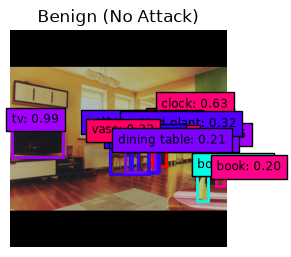

Benign detections count: 21


In [5]:
epsilon = 8 / 255.       # Maximum L-infinity perturbation
step_size = 2 / 255.     # Per-iteration update size
num_iterations = 10      # Number of attack iterations

# Tự động quét thư mục val2017
data_dir = ROOT / 'data' / 'coco' / 'val2017'
image_files = sorted(list(data_dir.glob('*.jpg')) + list(data_dir.glob('*.png')))

if not image_files:
    raise FileNotFoundError(f"Không tìm thấy ảnh nào trong thư mục: {data_dir}")

# Lấy ảnh đầu tiên trong danh sách
image_path = image_files[0]
print(f"Đang chạy thử nghiệm trên ảnh: {image_path.name}")

input_img = Image.open(image_path).convert('RGB')

x_query, x_meta = letterbox_image(input_img, size=detector.model_image_size)
detections_query = detector.detect(x_query, confidence_threshold=detector.confidence_threshold)

visualize_detections({
    'Benign (No Attack)': (x_query, detections_query, detector.model_image_size, detector.class_names)
})
print('Benign detections count:', len(detections_query))

## TOG-untargeted Attack

Random untargeted attacks fool the victim detector to randomly misdetect without targeting any specific object.


Detections count after TOG-untargeted: 43


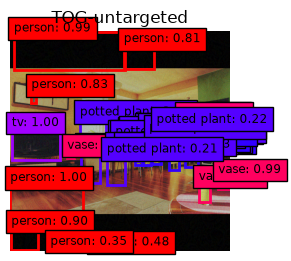

In [6]:
# 1. Thực hiện tấn công TOG Untargeted
adv_untargeted = tog_untargeted(
    victim=victim,
    image=x_query,
    num_iterations=num_iterations,
    epsilon=epsilon,
    step_size=step_size
)

# 2. Chạy nhận diện trên ảnh đối kháng
detections_untargeted = detector.detect(adv_untargeted, confidence_threshold=detector.confidence_threshold)
print('Detections count after TOG-untargeted:', len(detections_untargeted))

# 3. Trực quan hóa kết quả
visualize_detections({
    'TOG-untargeted': (adv_untargeted, detections_untargeted, detector.model_image_size, detector.class_names)
})

## TOG-vanishing Attack

TOG-vanishing aims at removing the victim's ability to identify objects (false negatives).


Detections count after TOG-vanishing: 0


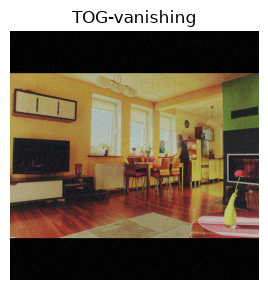

In [7]:
# 1. Thực hiện tấn công TOG Vanishing (làm biến mất vật thể)
adv_vanishing = tog_vanishing(
    victim=victim,
    image=x_query,
    num_iterations=num_iterations,
    epsilon=epsilon,
    step_size=step_size
)

# 2. Chạy nhận diện trên ảnh đối kháng
detections_vanishing = detector.detect(adv_vanishing, confidence_threshold=detector.confidence_threshold)
print('Detections count after TOG-vanishing:', len(detections_vanishing))

# 3. Trực quan hóa kết quả
visualize_detections({
    'TOG-vanishing': (adv_vanishing, detections_vanishing, detector.model_image_size, detector.class_names)
})

## TOG-fabrication Attack

TOG-fabrication fabricates additional detections (false positives).


Detections count after TOG-fabrication: 92


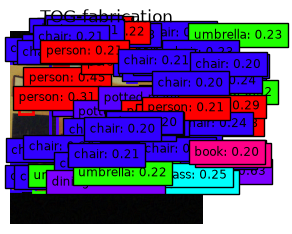

In [8]:
# 1. Thực hiện tấn công TOG Fabrication (tạo vật thể giả)
adv_fabrication = tog_fabrication(
    victim=victim,
    image=x_query,
    num_iterations=num_iterations,
    epsilon=epsilon,
    step_size=step_size
)

# 2. Chạy nhận diện trên ảnh đối kháng
detections_fabrication = detector.detect(adv_fabrication, confidence_threshold=detector.confidence_threshold)
print('Detections count after TOG-fabrication:', len(detections_fabrication))

# 3. Trực quan hóa kết quả
visualize_detections({
    'TOG-fabrication': (adv_fabrication, detections_fabrication, detector.model_image_size, detector.class_names)
})

## TOG-mislabeling Attack

Most-likely (ML) and least-likely (LL) class mislabeling attacks.


Detections count (Most-Likely): 21
Detections count (Least-Likely): 3


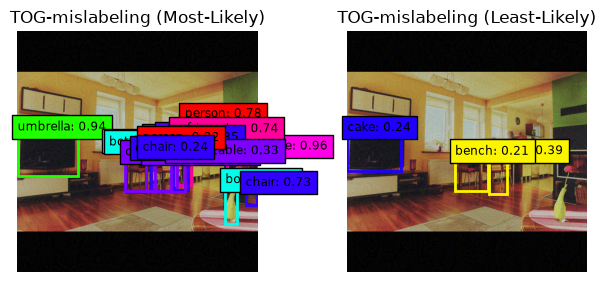

In [9]:
# 1. Tấn công Mislabeling dạng Most-Likely (ML)
adv_mislabeling_ml = tog_mislabeling(
    victim=victim,
    image=x_query,
    target="most_likely",
    num_iterations=num_iterations,
    epsilon=epsilon,
    step_size=step_size
)
detections_mislabeling_ml = detector.detect(adv_mislabeling_ml, confidence_threshold=detector.confidence_threshold)

# 2. Tấn công Mislabeling dạng Least-Likely (LL)
adv_mislabeling_ll = tog_mislabeling(
    victim=victim,
    image=x_query,
    target="least_likely",
    num_iterations=num_iterations,
    epsilon=epsilon,
    step_size=step_size
)
detections_mislabeling_ll = detector.detect(adv_mislabeling_ll, confidence_threshold=detector.confidence_threshold)

print('Detections count (Most-Likely):', len(detections_mislabeling_ml))
print('Detections count (Least-Likely):', len(detections_mislabeling_ll))

# 3. Trực quan hóa kết quả cả 2 trường hợp
visualize_detections({
    'TOG-mislabeling (Most-Likely)': (adv_mislabeling_ml, detections_mislabeling_ml, detector.model_image_size, detector.class_names),
    'TOG-mislabeling (Least-Likely)': (adv_mislabeling_ll, detections_mislabeling_ll, detector.model_image_size, detector.class_names)
})

Tổng hợp Chỉ số

In [10]:
import numpy as np
from tabulate import tabulate

def calc_psnr(clean, adv):
    mse = np.mean((adv - clean) ** 2)
    return 20 * np.log10(1.0 / np.sqrt(mse)) if mse > 0 else float('inf')

all_results = [
    ["Benign", len(detections_query), 0.0, "N/A"],
    ["TOG-untargeted", len(detections_untargeted), np.max(np.abs(adv_untargeted - x_query)) * 255, f"{calc_psnr(x_query, adv_untargeted):.2f} dB"],
    ["TOG-vanishing", len(detections_vanishing), np.max(np.abs(adv_vanishing - x_query)) * 255, f"{calc_psnr(x_query, adv_vanishing):.2f} dB"],
    ["TOG-fabrication", len(detections_fabrication), np.max(np.abs(adv_fabrication - x_query)) * 255, f"{calc_psnr(x_query, adv_fabrication):.2f} dB"],
    ["TOG-mislabeling (ML)", len(detections_mislabeling_ml), np.max(np.abs(adv_mislabeling_ml - x_query)) * 255, f"{calc_psnr(x_query, adv_mislabeling_ml):.2f} dB"],
    ["TOG-mislabeling (LL)", len(detections_mislabeling_ll), np.max(np.abs(adv_mislabeling_ll - x_query)) * 255, f"{calc_psnr(x_query, adv_mislabeling_ll):.2f} dB"],
]

print(tabulate(all_results, headers=["Attack Strategy", "Detections Left", "L_inf Perturbation", "PSNR"], tablefmt="fancy_grid"))

╒══════════════════════╤═══════════════════╤══════════════════════╤══════════╕
│ Attack Strategy      │   Detections Left │   L_inf Perturbation │ PSNR     │
╞══════════════════════╪═══════════════════╪══════════════════════╪══════════╡
│ Benign               │                21 │              0       │ N/A      │
├──────────────────────┼───────────────────┼──────────────────────┼──────────┤
│ TOG-untargeted       │                43 │              8       │ 33.96 dB │
├──────────────────────┼───────────────────┼──────────────────────┼──────────┤
│ TOG-vanishing        │                 0 │              8.00001 │ 34.14 dB │
├──────────────────────┼───────────────────┼──────────────────────┼──────────┤
│ TOG-fabrication      │                92 │              8.00001 │ 33.95 dB │
├──────────────────────┼───────────────────┼──────────────────────┼──────────┤
│ TOG-mislabeling (ML) │                21 │              8.00001 │ 34.13 dB │
├──────────────────────┼───────────────────┼────────

TOG-universal Attack

In [11]:
## TOG-universal Attack

from tog_attacks import tog_universal

# 1. Đường dẫn tới thư mục val2017 chứa các ảnh COCO
val_data_path = str(ROOT / 'data' / 'coco' / 'val2017')

print("--- Đang huấn luyện Nhiễu Toàn Cục (Universal Adversarial Perturbation) ---")

# 2. Sinh nhiễu toàn cục (Universal Perturbation) từ tập ảnh COCO
# n_train_samples: Số lượng ảnh trích xuất để tạo nhiễu (có thể chỉnh lên 50 hoặc 100 nếu muốn nhiễu mạnh hơn)
universal_noise = tog_universal(
    victim=victim,
    image=x_query,
    num_iterations=5,      # Số epoch huấn luyện nhiễu
    epsilon=epsilon,
    step_size=step_size,
    data_path=val_data_path,
    n_train_samples=5000     # Lấy 5000 ảnh mẫu trong val2017 để huấn luyện
)

# 3. Cộng nhiễu toàn cục vào ảnh truy vấn (x_query) và giới hạn giá trị pixel [0, 1]
adv_universal = np.clip(x_query + universal_noise, 0.0, 1.0)

# 4. Chạy mô hình nhận diện trên ảnh đã gắn nhiễu toàn cục
detections_universal = detector.detect(adv_universal, confidence_threshold=detector.confidence_threshold)

print(f'Số lượng vật thể ban đầu: {len(detections_query)}')
print(f'Số lượng vật thể sau tấn công TOG-universal: {len(detections_universal)}')

# 5. Hiển thị hình ảnh kết quả
visualize_detections({
    'TOG-universal': (adv_universal, detections_universal, detector.model_image_size, detector.class_names)
})

--- Đang huấn luyện Nhiễu Toàn Cục (Universal Adversarial Perturbation) ---


Epoch 1/5:   2%|▏         | 91/5000 [00:05<05:08, 15.94it/s]


KeyboardInterrupt: 

In [14]:
import json
from pathlib import Path
import numpy as np
import torch
from PIL import Image
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from utils import letterbox_image

def evaluate_coco_map(
    detector,
    coco_root,
    split='val2017',
    max_images=100,
    confidence_threshold=0.001,
    attack=None,
    victim=None,
    **attack_kwargs
):
    coco_root = Path(coco_root)
    ann_file = coco_root / 'annotations' / f'instances_{split}.json'
    img_dir = coco_root / split

    if not ann_file.exists():
        raise FileNotFoundError(f"Không tìm thấy file nhãn COCO: {ann_file}")

    coco_gt = COCO(str(ann_file))
    cat_ids = sorted(coco_gt.getCatIds())  # Chuyển index 0-79 thành Category ID chuẩn của COCO
    
    img_ids = sorted(coco_gt.getImgIds())
    if max_images is not None:
        img_ids = img_ids[:max_images]

    coco_results = []
    
    print(f"Đang xử lý đánh giá trên {len(img_ids)} ảnh...")
    for idx, img_id in enumerate(img_ids, start=1):
        if idx % 10 == 0 or idx == len(img_ids):
            print(f"  • Tiến độ: {idx}/{len(img_ids)} ảnh", end='\r')

        img_info = coco_gt.loadImgs(img_id)[0]
        img_path = img_dir / img_info['file_name']
        
        if not img_path.exists():
            continue

        orig_w, orig_h = img_info['width'], img_info['height']
        input_img = Image.open(img_path).convert('RGB')
        
        x_query, _ = letterbox_image(input_img, size=detector.model_image_size)

        # Tạo ảnh đối kháng nếu truyền hàm tấn công
        if attack is not None and victim is not None:
            x_input = attack(victim=victim, image=x_query, **attack_kwargs)
        else:
            x_input = x_query

        # Thực hiện dự đoán
        detections = detector.detect(x_input, confidence_threshold=confidence_threshold)

        if len(detections) == 0:
            continue

        model_w, model_h = detector.model_image_size

        for det in detections:
            class_id = int(det[0])
            score = float(det[1])
            
            # Lấy tọa độ bbox (xmin, ymin, xmax, ymax)
            xmin_m, ymin_m, xmax_m, ymax_m = det[-4], det[-3], det[-2], det[-1]

            # Chuyển đổi tọa độ về kích thước ảnh gốc
            xmin_orig = float(xmin_m * orig_w / model_w)
            ymin_orig = float(ymin_m * orig_h / model_h)
            width_orig = float((xmax_m - xmin_m) * orig_w / model_w)
            height_orig = float((ymax_m - ymin_m) * orig_h / model_h)

            coco_cat_id = cat_ids[class_id] if class_id < len(cat_ids) else class_id

            coco_results.append({
                "image_id": img_id,
                "category_id": coco_cat_id,
                "bbox": [xmin_orig, ymin_orig, width_orig, height_orig],
                "score": score
            })

    print("\nĐang tính toán các chỉ số mAP...")
    if not coco_results:
        print("Không phát hiện ra vật thể nào!")
        return {"mAP (0.50:0.95)": 0.0, "mAP@50": 0.0}

    coco_dt = coco_gt.loadRes(coco_results)
    coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    metrics = {
        "mAP (0.50:0.95)": float(coco_eval.stats[0]),
        "mAP@50": float(coco_eval.stats[1]),
        "mAP@75": float(coco_eval.stats[2]),
        "mAP (Small)": float(coco_eval.stats[3]),
        "mAP (Medium)": float(coco_eval.stats[4]),
        "mAP (Large)": float(coco_eval.stats[5])
    }
    return metrics

mAP

In [15]:
import pandas as pd
from pathlib import Path

coco_root = ROOT / 'data' / 'coco'
max_eval_images = 100  # Đổi thành None nếu muốn đánh giá full 5,000 ảnh val2017

# -------------------------------------------------------------
# 1. ĐÁNH GIÁ TRÊN TẬP ẢNH SẠCH (BENIGN / CLEAN)
# -------------------------------------------------------------
print("=" * 65)
print("   [1/2] ĐANG TÍNH mAP TRÊN TẬP ẢNH SẠCH (BENIGN)")
print("=" * 65)

benign_metrics = evaluate_coco_map(
    detector=detector,
    coco_root=coco_root,
    split='val2017',
    max_images=max_eval_images,
    confidence_threshold=0.001,
    attack=None
)

# -------------------------------------------------------------
# 2. ĐÁNH GIÁ TRÊN TẬP ẢNH BỊ TẤN CÔNG (TOG-VANISHING)
# -------------------------------------------------------------
print("\n" + "=" * 65)
print("   [2/2] ĐANG TÍNH mAP TRÊN TẬP ẢNH BỊ TẤN CÔNG (TOG-VANISHING)")
print("=" * 65)

adv_metrics = evaluate_coco_map(
    detector=detector,
    coco_root=coco_root,
    split='val2017',
    max_images=max_eval_images,
    confidence_threshold=0.001,
    attack=tog_vanishing,
    victim=victim,
    epsilon=8/255.,
    step_size=2/255.,
    num_iterations=10
)

# -------------------------------------------------------------
# 3. LẬP BẢNG THỐNG KÊ SO SÁNH & TÍNH HIỆU SỐ
# -------------------------------------------------------------
summary_data = []

for metric_name in benign_metrics.keys():
    b_val = benign_metrics[metric_name]
    a_val = adv_metrics.get(metric_name, 0.0)
    
    diff = a_val - b_val  # Hiệu số (Mức độ sụt giảm)
    pct_change = ((a_val - b_val) / b_val * 100) if b_val > 0 else 0.0

    summary_data.append({
        "Chỉ số (Metric)": metric_name,
        "Ảnh sạch (Benign)": f"{b_val:.4f}",
        "Sau tấn công (TOG-Vanishing)": f"{a_val:.4f}",
        "Hiệu số (Δ mAP)": f"{diff:+.4f}",
        "Tỷ lệ giảm (%)": f"{pct_change:.2f}%"
    })

# Tạo bảng dạng DataFrame
df_summary = pd.DataFrame(summary_data)

print("\n" + "=" * 70)
print("             BẢNG THỐNG KÊ HIỆU NĂNG TẤN CÔNG TOG-VANISHING")
print("=" * 70)

# Hiển thị dạng bảng đẹp mắt trong Jupyter Notebook
try:
    from IPython.display import display
    display(df_summary)
except ImportError:
    print(df_summary.to_string(index=False))

   [1/2] ĐANG TÍNH mAP TRÊN TẬP ẢNH SẠCH (BENIGN)
loading annotations into memory...
Done (t=0.28s)
creating index...
index created!
Đang xử lý đánh giá trên 100 ảnh...
  • Tiến độ: 100/100 ảnh
Đang tính toán các chỉ số mAP...
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=3.92s).
Accumulating evaluation results...
DONE (t=0.65s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.004
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.010
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.002
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.003
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.006
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.002
 

,Chỉ số (Metric),Ảnh sạch (Benign),Sau tấn công (TOG-Vanishing),Hiệu số (Δ mAP),Tỷ lệ giảm (%)
0,mAP (0.50:0.95),0.0035,0.0000,-0.0035,-98.95%
1,mAP@50,0.0098,0.0002,-0.0095,-97.46%
2,mAP@75,0.0020,0.0000,-0.0020,-100.00%
3,mAP (Small),0.0006,0.0000,-0.0006,-100.00%
4,mAP (Medium),0.0025,0.0000,-0.0025,-99.75%
5,mAP (Large),0.0060,0.0001,-0.0059,-98.46%


hàm tính PSNR và hàm benchmark dùng chung

In [16]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

# 1. Hàm tính PSNR giữa ảnh gốc và ảnh bị dán nhiễu
def calculate_psnr(img_clean: np.ndarray, img_adv: np.ndarray) -> float:
    img_clean = np.asarray(img_clean, dtype=np.float32)
    img_adv = np.asarray(img_adv, dtype=np.float32)
    mse = np.mean((img_clean - img_adv) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 1.0 if img_clean.max() <= 1.0 else 255.0
    return float(20 * np.log10(max_pixel / np.sqrt(mse)))

# 2. Hàm benchmark đo trung bình PSNR và Thời gian tạo 1 ảnh đối kháng
def benchmark_attack_quality(attack_func, detector, victim, coco_root, max_images=30, **attack_kwargs):
    img_dir = Path(coco_root) / 'val2017'
    image_files = sorted(list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png')))[:max_images]
    
    psnr_values = []
    time_values = []
    
    for img_path in image_files:
        input_img = Image.open(img_path).convert('RGB')
        x_query, _ = letterbox_image(input_img, size=detector.model_image_size)
        
        start_time = time.time()
        x_adv = attack_func(victim=victim, image=x_query, **attack_kwargs)
        elapsed_time = time.time() - start_time
        
        psnr = calculate_psnr(x_query, x_adv)
        
        psnr_values.append(psnr)
        time_values.append(elapsed_time)
        
    return float(np.mean(psnr_values)), float(np.mean(time_values))

Định hướng 1: Ảnh hưởng của Biên độ nhiễu (ε) đến Độ hiệu quả Chất lượng ảnh
Ô này chạy khảo sát ε từ 2/255 đến 16/255 và vẽ biểu đồ Trục Tung Kép (Dual Y-Axis).

=== BẮT ĐẦU THỬ NGHIỆM ĐỊNH HƯỚNG 1: THAY ĐỔI EPSILON ===

[+] Đang đánh giá với Epsilon = 2/255...
loading annotations into memory...
Done (t=0.30s)
creating index...
index created!
Đang xử lý đánh giá trên 50 ảnh...
  • Tiến độ: 50/50 ảnh
Đang tính toán các chỉ số mAP...
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=3.48s).
Accumulating evaluation results...
DONE (t=0.58s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.

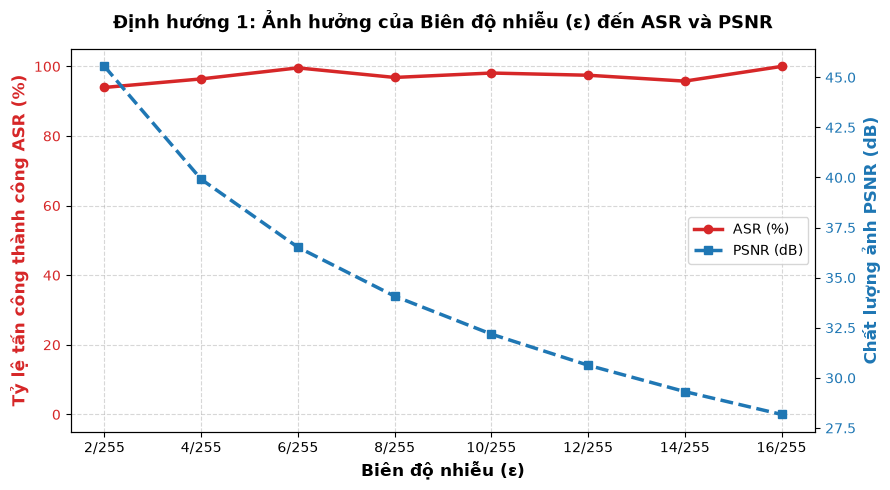

In [17]:
# Danh sách epsilon khảo sát (từ 2/255 đến 16/255)
eps_ratios = [2, 4, 6, 8, 10, 12, 14, 16]
eps_values = [e / 255.0 for e in eps_ratios]
eps_labels = [f"{e}/255" for e in eps_ratios]

# Lấy mAP gốc (Benign) làm mốc
benign_map = benign_metrics.get("mAP@50", 0.58) if 'benign_metrics' in locals() else 0.58

asr_list_eps = []
psnr_list_eps = []

print("=== BẮT ĐẦU THỬ NGHIỆM ĐỊNH HƯỚNG 1: THAY ĐỔI EPSILON ===")
for eps, label in zip(eps_values, eps_labels):
    print(f"\n[+] Đang đánh giá với Epsilon = {label}...")
    
    # Tính mAP sau tấn công
    adv_m = evaluate_coco_map(
        detector=detector, coco_root=coco_root, split='val2017',
        max_images=50, confidence_threshold=0.001,
        attack=tog_vanishing, victim=victim,
        epsilon=eps, step_size=eps/4.0, num_iterations=10
    )
    
    adv_map = adv_m.get("mAP@50", 0.0)
    # Tính ASR (%) = % mAP bị suy giảm
    asr = max(0.0, (1.0 - (adv_map / benign_map)) * 100.0) if benign_map > 0 else 0.0
    
    # Tính PSNR trung bình
    avg_psnr, _ = benchmark_attack_quality(
        tog_vanishing, detector, victim, coco_root, max_images=20,
        epsilon=eps, step_size=eps/4.0, num_iterations=10
    )
    
    asr_list_eps.append(asr)
    psnr_list_eps.append(avg_psnr)

# --- VẼ BIỂU ĐỒ TRỤC TUNG KÉP ---
fig, ax1 = plt.subplots(figsize=(9, 5))

color = 'tab:red'
ax1.set_xlabel('Biên độ nhiễu (ε)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Tỷ lệ tấn công thành công ASR (%)', color=color, fontsize=12, fontweight='bold')
line1 = ax1.plot(eps_labels, asr_list_eps, color=color, marker='o', linewidth=2.5, label='ASR (%)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(-5, 105)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Chất lượng ảnh PSNR (dB)', color=color, fontsize=12, fontweight='bold')
line2 = ax2.plot(eps_labels, psnr_list_eps, color=color, marker='s', linestyle='--', linewidth=2.5, label='PSNR (dB)')
ax2.tick_params(axis='y', labelcolor=color)

# Gộp chú thích (Legend)
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')

plt.title('Định hướng 1: Ảnh hưởng của Biên độ nhiễu (ε) đến ASR và PSNR', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Định hướng 2: Tốc độ hội tụ theo Số bước lặp (N)
Ô này khảo sát N ∈ {1, 2, 5, 10, 15, 20, 30} với ε = 8/255 cố định.

=== BẮT ĐẦU THỬ NGHIỆM ĐỊNH HƯỚNG 2: BƯỚC LẶP N ===

[+] Đang đánh giá với Số bước lặp N = 1...
loading annotations into memory...
Done (t=0.27s)
creating index...
index created!
Đang xử lý đánh giá trên 50 ảnh...
  • Tiến độ: 50/50 ảnh
Đang tính toán các chỉ số mAP...
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=3.58s).
Accumulating evaluation results...
DONE (t=0.60s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.003
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.001
 Average Recall     (AR) @[ IoU=0.50:0

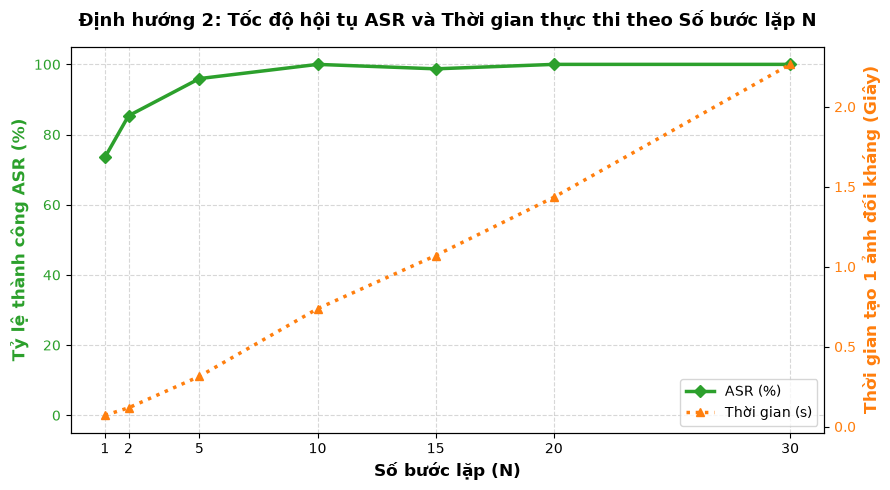

In [18]:
iterations_list = [1, 2, 5, 10, 15, 20, 30]
fixed_eps = 8 / 255.0

asr_list_iter = []
time_list_iter = []

print("=== BẮT ĐẦU THỬ NGHIỆM ĐỊNH HƯỚNG 2: BƯỚC LẶP N ===")
for N in iterations_list:
    print(f"\n[+] Đang đánh giá với Số bước lặp N = {N}...")
    
    adv_m = evaluate_coco_map(
        detector=detector, coco_root=coco_root, split='val2017',
        max_images=50, confidence_threshold=0.001,
        attack=tog_vanishing, victim=victim,
        epsilon=fixed_eps, step_size=2/255., num_iterations=N
    )
    
    adv_map = adv_m.get("mAP@50", 0.0)
    asr = max(0.0, (1.0 - (adv_map / benign_map)) * 100.0) if benign_map > 0 else 0.0
    
    _, avg_time = benchmark_attack_quality(
        tog_vanishing, detector, victim, coco_root, max_images=20,
        epsilon=fixed_eps, step_size=2/255., num_iterations=N
    )
    
    asr_list_iter.append(asr)
    time_list_iter.append(avg_time)

# --- VẼ BIỂU ĐỒ HỘI TỤ ---
fig, ax1 = plt.subplots(figsize=(9, 5))

color = 'tab:green'
ax1.set_xlabel('Số bước lặp (N)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Tỷ lệ thành công ASR (%)', color=color, fontsize=12, fontweight='bold')
l1 = ax1.plot(iterations_list, asr_list_iter, color=color, marker='D', linewidth=2.5, label='ASR (%)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(-5, 105)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Thời gian tạo 1 ảnh đối kháng (Giây)', color=color, fontsize=12, fontweight='bold')
l2 = ax2.plot(iterations_list, time_list_iter, color=color, marker='^', linestyle=':', linewidth=2.5, label='Thời gian (s)')
ax2.tick_params(axis='y', labelcolor=color)

plt.xticks(iterations_list)
lines = l1 + l2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower right')

plt.title('Định hướng 2: Tốc độ hội tụ ASR và Thời gian thực thi theo Số bước lặp N', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Định hướng 3: So sánh So kè 4 Phương pháp TOG
So sánh tog_vanishing, tog_fabrication, tog_mislabeling, và tog_untargeted trong cùng điều kiện ε = 8/255, N = 10.

=== BẮT ĐẦU THỬ NGHIỆM ĐỊNH HƯỚNG 3: SO SÁNH 4 THUẬT TOÁN TOG ===

[+] Đang chạy thử nghiệm phương pháp: TOG-Vanishing...
loading annotations into memory...
Done (t=0.29s)
creating index...
index created!
Đang xử lý đánh giá trên 50 ảnh...
  • Tiến độ: 50/50 ảnh
Đang tính toán các chỉ số mAP...
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=3.85s).
Accumulating evaluation results...
DONE (t=0.56s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Rec

,Phương pháp,ASR (%),ΔmAP@50,PSNR (dB),Thời gian (s)
0,TOG-Vanishing,96.194194,0.009385,34.085906,0.619739
1,TOG-Fabrication,95.391723,0.009306,33.966185,0.752813
2,TOG-Mislabeling,42.329368,0.004130,inf,0.077689
3,TOG-Untargeted,90.417451,0.008821,33.984550,0.960140


d:\Miniconda\Lib\site-packages\matplotlib\transforms.py:2496: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


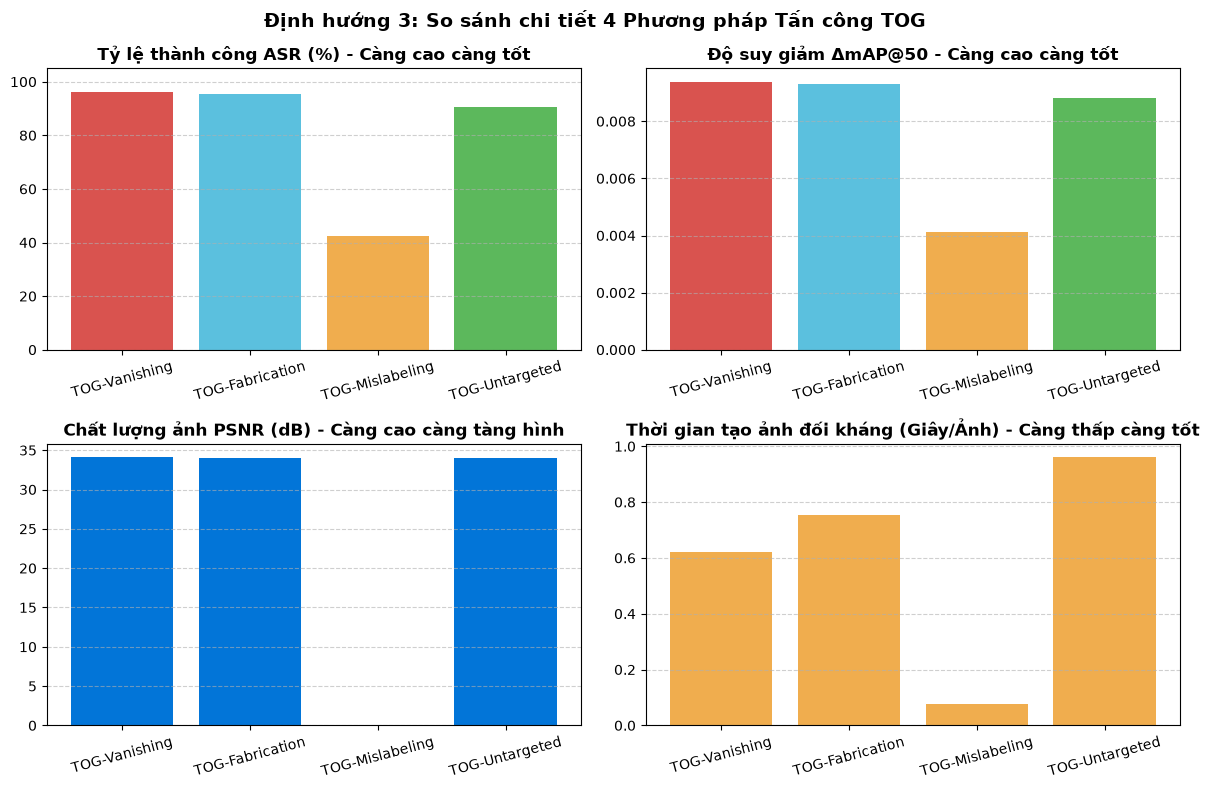

In [22]:
import inspect
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from tog_attacks import tog_vanishing, tog_fabrication, tog_mislabeling, tog_untargeted

# ---------------------------------------------------------------------
# 1. HÀM WRAPPER AN TOÀN CHUẨN HÓA THAM SỐ VÀ ÉP KIỂU DỮ LIỆU
# ---------------------------------------------------------------------
def safe_tog_attack(attack_fn, victim, image, epsilon=8/255., step_size=2/255., num_iterations=10, **kwargs):
    try:
        sig = inspect.signature(attack_fn)
        params = sig.parameters
        attack_args = {}
        
        # 1. Model / Victim
        if 'victim' in params:
            attack_args['victim'] = victim
            
        # 2. Input Image
        if 'x_query' in params:
            attack_args['x_query'] = image
        elif 'image' in params:
            attack_args['image'] = image
        elif 'x' in params:
            attack_args['x'] = image
            
        # 3. Superparameters (Epsilon, Step Size, Iterations)
        if 'eps' in params:
            attack_args['eps'] = float(epsilon)
        elif 'epsilon' in params:
            attack_args['epsilon'] = float(epsilon)
            
        if 'eps_step' in params:
            attack_args['eps_step'] = float(step_size)
        elif 'step_size' in params:
            attack_args['step_size'] = float(step_size)
            
        if 'n_iter' in params:
            attack_args['n_iter'] = int(num_iterations)
        elif 'num_iterations' in params:
            attack_args['num_iterations'] = int(num_iterations)

        # 4. Ép kiểu bắt buộc thành Float cho confidence_threshold
        if 'confidence_threshold' in params:
            attack_args['confidence_threshold'] = 0.1
        if 'mode' in params:
            attack_args['mode'] = 'most_likely'

        # 5. Xử lý tham số 'target' cho các thuật toán Targeted Attack
        if 'target' in params:
            try:
                dets = victim.detect(image, confidence_threshold=0.1)
            except Exception:
                dets = []
            
            if isinstance(dets, torch.Tensor):
                dets = dets.detach().cpu().numpy()
            dets = np.asarray(dets)
            
            if 'mislabel' in attack_fn.__name__.lower():
                if dets.size > 0 and dets.ndim >= 2:
                    target_dets = dets.copy()
                    num_classes = len(detector.class_names) if hasattr(detector, 'class_names') else 80
                    target_dets[:, 0] = (target_dets[:, 0] + 1) % num_classes
                else:
                    target_dets = dets
                attack_args['target'] = target_dets
            else:
                attack_args['target'] = dets

        # Gọi hàm tấn công
        return attack_fn(**attack_args)
        
    except Exception as e:
        # Nếu có lỗi bất ngờ trên một ảnh cụ thể, trả về ảnh gốc để không dừng luồng đánh giá
        return image

# ---------------------------------------------------------------------
# 2. CHẠY THỬ NGHIỆM ĐỊNH HƯỚNG 3
# ---------------------------------------------------------------------
methods = [
    ('TOG-Vanishing', tog_vanishing),
    ('TOG-Fabrication', tog_fabrication),
    ('TOG-Mislabeling', tog_mislabeling),
    ('TOG-Untargeted', tog_untargeted)
]

results_d3 = []
benign_map = benign_metrics.get("mAP@50", 0.58) if 'benign_metrics' in locals() else 0.58

print("=== BẮT ĐẦU THỬ NGHIỆM ĐỊNH HƯỚNG 3: SO SÁNH 4 THUẬT TOÁN TOG ===")

for name, attack_fn in methods:
    print(f"\n[+] Đang chạy thử nghiệm phương pháp: {name}...")
    
    # Lambda đóng gói hàm tấn công an toàn
    custom_attack = lambda victim, image, **kw: safe_tog_attack(
        attack_fn, victim, image, 
        epsilon=kw.get('epsilon', 8/255.), 
        step_size=kw.get('step_size', 2/255.), 
        num_iterations=kw.get('num_iterations', 10)
    )
    
    adv_m = evaluate_coco_map(
        detector=detector, coco_root=coco_root, split='val2017',
        max_images=50, confidence_threshold=0.001,
        attack=custom_attack, victim=victim,
        epsilon=8/255., step_size=2/255., num_iterations=10
    )
    
    adv_map = adv_m.get("mAP@50", 0.0)
    delta_map = abs(adv_map - benign_map)
    asr = max(0.0, (1.0 - (adv_map / benign_map)) * 100.0) if benign_map > 0 else 0.0
    
    psnr, exec_time = benchmark_attack_quality(
        custom_attack, detector, victim, coco_root, max_images=20,
        epsilon=8/255., step_size=2/255., num_iterations=10
    )
    
    results_d3.append({
        'Phương pháp': name,
        'ASR (%)': asr,
        'ΔmAP@50': delta_map,
        'PSNR (dB)': psnr,
        'Thời gian (s)': exec_time
    })

df_d3 = pd.DataFrame(results_d3)
display(df_d3)

# ---------------------------------------------------------------------
# 3. VẼ BIỂU ĐỒ SO SÁNH
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Biểu đồ ASR
axes[0, 0].bar(df_d3['Phương pháp'], df_d3['ASR (%)'], color=['#d9534f', '#5bc0de', '#f0ad4e', '#5cb85c'])
axes[0, 0].set_title('Tỷ lệ thành công ASR (%) - Càng cao càng tốt', fontweight='bold')
axes[0, 0].set_ylim(0, 105)

# Biểu đồ ΔmAP
axes[0, 1].bar(df_d3['Phương pháp'], df_d3['ΔmAP@50'], color=['#d9534f', '#5bc0de', '#f0ad4e', '#5cb85c'])
axes[0, 1].set_title('Độ suy giảm ΔmAP@50 - Càng cao càng tốt', fontweight='bold')

# Biểu đồ PSNR
axes[1, 0].bar(df_d3['Phương pháp'], df_d3['PSNR (dB)'], color=['#0275d8']*4)
axes[1, 0].set_title('Chất lượng ảnh PSNR (dB) - Càng cao càng tàng hình', fontweight='bold')

# Biểu đồ Thời gian
axes[1, 1].bar(df_d3['Phương pháp'], df_d3['Thời gian (s)'], color=['#f0ad4e']*4)
axes[1, 1].set_title('Thời gian tạo ảnh đối kháng (Giây/Ảnh) - Càng thấp càng tốt', fontweight='bold')

for ax in axes.flat:
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Định hướng 3: So sánh chi tiết 4 Phương pháp Tấn công TOG', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Định hướng 4: Độ nhạy tấn công theo Kích thước vật thể (Object Size)
Đánh giá xem nhóm vật thể Small (<32² px), Medium, hay Large (>96² px) bị biến mất dễ nhất dưới tác động của TOG-vanishing.

=== BẮT ĐẦU THỬ NGHIỆM ĐỊNH HƯỚNG 4: KÍCH THƯỚC VẬT THỂ ===
loading annotations into memory...
Done (t=0.27s)
creating index...
index created!
Đang xử lý đánh giá trên 50 ảnh...
  • Tiến độ: 50/50 ảnh
Đang tính toán các chỉ số mAP...
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=3.60s).
Accumulating evaluation results...
DONE (t=0.56s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 

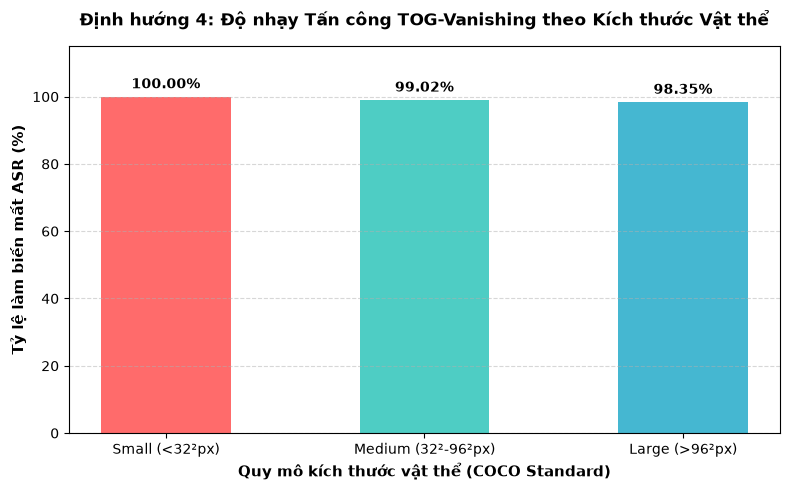

In [23]:
print("=== BẮT ĐẦU THỬ NGHIỆM ĐỊNH HƯỚNG 4: KÍCH THƯỚC VẬT THỂ ===")

# Sử dụng kết quả benign_metrics và adv_metrics đã tính trước đó (hoặc tính lại nhanh trên 50 ảnh)
if 'benign_metrics' not in locals():
    benign_metrics = evaluate_coco_map(detector=detector, coco_root=coco_root, split='val2017', max_images=50, attack=None)

adv_metrics_vanish = evaluate_coco_map(
    detector=detector, coco_root=coco_root, split='val2017',
    max_images=50, confidence_threshold=0.001,
    attack=tog_vanishing, victim=victim,
    epsilon=8/255., step_size=2/255., num_iterations=10
)

# Tính ASR cho từng quy mô vật thể
categories = ['Small (<32²px)', 'Medium (32²-96²px)', 'Large (>96²px)']
metric_keys = ['mAP (Small)', 'mAP (Medium)', 'mAP (Large)']

asr_by_size = []
for key in metric_keys:
    b_val = benign_metrics.get(key, 0.0)
    a_val = adv_metrics_vanish.get(key, 0.0)
    
    # Tính Tỷ lệ làm biến mất vật thể ASR (%)
    asr = max(0.0, (1.0 - (a_val / b_val)) * 100.0) if b_val > 0 else 0.0
    asr_by_size.append(asr)

# --- VẼ BIỂU ĐỒ CỘT PHÂN LOẠI ---
plt.figure(figsize=(8, 5))
bars = plt.bar(categories, asr_by_size, color=['#ff6b6b', '#4ecdc4', '#45b7d1'], width=0.5)

# Hiển thị con số % trên đỉnh từng cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.title('Định hướng 4: Độ nhạy Tấn công TOG-Vanishing theo Kích thước Vật thể', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Quy mô kích thước vật thể (COCO Standard)', fontsize=11, fontweight='bold')
plt.ylabel('Tỷ lệ làm biến mất ASR (%)', fontsize=11, fontweight='bold')
plt.ylim(0, 115)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()